In [27]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/stroke-prediction-dataset


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv(path + "/healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [32]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64


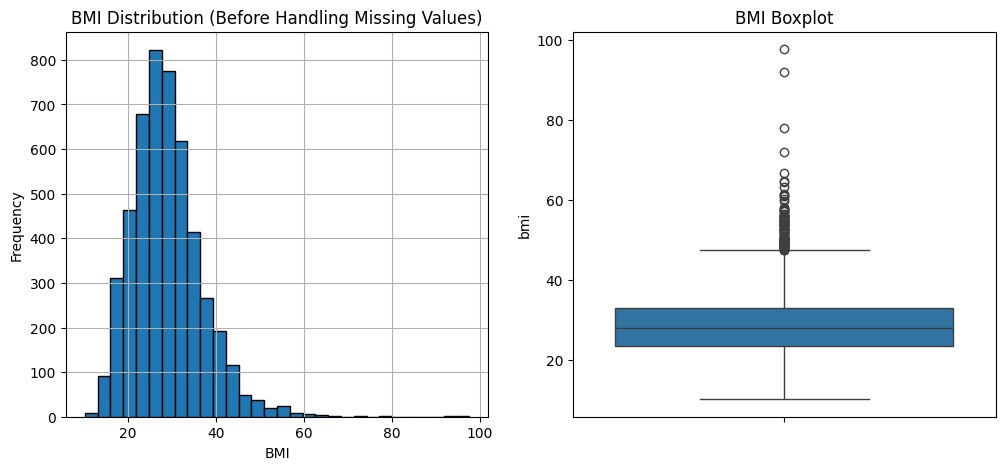

In [33]:
print(df['bmi'].describe())
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['bmi'].hist(bins=30, edgecolor='black')
plt.title('BMI Distribution (Before Handling Missing Values)')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['bmi'])
plt.title('BMI Boxplot')
plt.show()

Handling BMI null values


In [34]:
bmi_median = df['bmi'].median()
df['bmi'].fillna(bmi_median, inplace=True)
print(f"\nBMI missing values filled with median: {bmi_median:.2f}")
print("\nBMI Statistics After Handling:")
print(df['bmi'].describe())
print(f"\nRemaining null values: {df.isnull().sum().sum()}")


BMI missing values filled with median: 28.10

BMI Statistics After Handling:
count    5110.000000
mean       28.862035
std         7.699562
min        10.300000
25%        23.800000
50%        28.100000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64

Remaining null values: 0


Stroke Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke Percentage:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


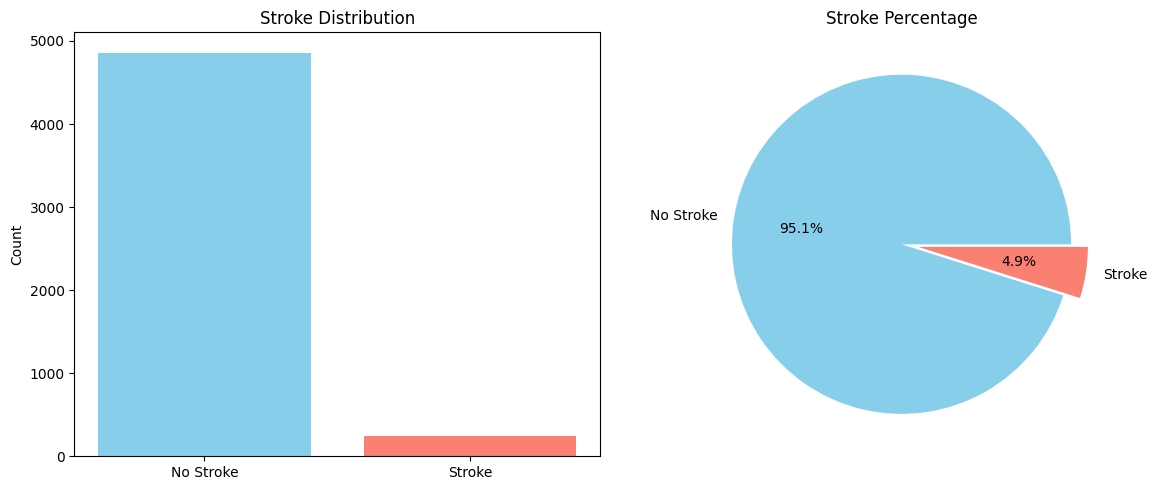


Correlation with Stroke:
stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.036110
Name: stroke, dtype: float64


In [35]:
print("Stroke Distribution:")
print(df['stroke'].value_counts())
print(f"\nStroke Percentage:")
print(df['stroke'].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['No Stroke', 'Stroke'], df['stroke'].value_counts(), color=['skyblue', 'salmon'])
axes[0].set_title('Stroke Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(df['stroke'].value_counts(), labels=['No Stroke', 'Stroke'], autopct='%1.1f%%',
            colors=['skyblue', 'salmon'], explode=(0, 0.1))
axes[1].set_title('Stroke Percentage')

plt.tight_layout()
plt.show()
print("\nCorrelation with Stroke:")
correlation = df[['age', 'bmi', 'avg_glucose_level', 'hypertension', 'heart_disease', 'stroke']].corr()
print(correlation['stroke'].sort_values(ascending=False))

Using label encoding for binary columns like gender, married etc


In [36]:
categorical_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

print("Categorical Columns:")
for col in categorical_columns:
    print(f"\n{col}: {df[col].unique()}")

label_encoders = {}
for col in ['gender', 'ever_married', 'Residence_type']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"\nEncoded {col}:")
    for original, encoded in zip(le.classes_, le.transform(le.classes_)):
        print(f"  {original} -> {encoded}")


Categorical Columns:

gender: ['Male' 'Female' 'Other']

ever_married: ['Yes' 'No']

work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Residence_type: ['Urban' 'Rural']

smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']

Encoded gender:
  Female -> 0
  Male -> 1
  Other -> 2

Encoded ever_married:
  No -> 0
  Yes -> 1

Encoded Residence_type:
  Rural -> 0
  Urban -> 1


using onehotencoder for multi-category columns

In [37]:
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'], prefix=['work', 'smoke'])

print(f"\nDataset shape after encoding: {df.shape}")


Dataset shape after encoding: (5110, 19)


In [38]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'work_Govt_job',
       'work_Never_worked', 'work_Private', 'work_Self-employed',
       'work_children', 'smoke_Unknown', 'smoke_formerly smoked',
       'smoke_never smoked', 'smoke_smokes'],
      dtype='object')

Cleaning data, droping id


In [39]:
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
    print("Dropped 'id' column")

Dropped 'id' column


In [40]:
X = df.drop('stroke', axis=1)
y = df['stroke']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures columns ({len(X.columns)} total):")

Features shape: (5110, 17)
Target shape: (5110,)

Features columns (17 total):


In [41]:
X.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'work_Govt_job',
       'work_Never_worked', 'work_Private', 'work_Self-employed',
       'work_children', 'smoke_Unknown', 'smoke_formerly smoked',
       'smoke_never smoked', 'smoke_smokes'],
      dtype='object')

x and y split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42, stratify=y
)

In [44]:
X_train.shape

(4088, 17)

training set = 4088
testing set = 17

In [45]:
y_train.value_counts(normalize=True)

,proportion
stroke,
0,0.951321
1,0.048679


Now for numerical columns

In [46]:
numerical_features = ['age', 'avg_glucose_level', 'bmi']
print("Before Scaling:")
for col in numerical_features:
    print(f"{col}: mean={X_train[col].mean():.2f}, std={X_train[col].std():.2f}")



Before Scaling:
age: mean=43.35, std=22.60
avg_glucose_level: mean=106.32, std=45.26
bmi: mean=28.89, std=7.76


In [47]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("\nAfter Scaling:")
for col in numerical_features:
    print(f"{col}: mean={X_train_scaled[col].mean():.2f}, std={X_train_scaled[col].std():.2f}")


After Scaling:
age: mean=-0.00, std=1.00
avg_glucose_level: mean=0.00, std=1.00
bmi: mean=-0.00, std=1.00


Building Artifical neural network model

In [48]:
model = models.Sequential([

    layers.Input(shape=(X_train_scaled.shape[1],)),  #input layer


    #hidden layer
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid') # outer
])


In [49]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

In [51]:
print("Model Architecture:")
model.summary()

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,145 (55.25 KB)

 Trainable params: 13,665 (53.38 KB)

 Non-trainable params: 480 (1.88 KB)

In [52]:
total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters: 14,145
Trainable parameters: 13,665


Training ANN model

preventing overfitting


In [53]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

introducing weights to handle imbalancing

In [54]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

Class weights: {0: np.float64(0.5255849832861919), 1: np.float64(10.271356783919598)}


In [55]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

print(f"\nTraining completed!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best validation loss: {min(history.history['val_loss']):.4f}")

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5183 - loss: 0.7992 - precision: 0.0605 - recall: 0.6447 - val_accuracy: 0.9034 - val_loss: 0.5563 - val_precision: 0.2037 - val_recall: 0.2340
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5911 - loss: 0.6428 - precision: 0.0813 - recall: 0.7566 - val_accuracy: 0.8301 - val_loss: 0.4981 - val_precision: 0.1667 - val_recall: 0.4894
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6483 - loss: 0.6091 - precision: 0.0890 - recall: 0.7105 - val_accuracy: 0.8178 - val_loss: 0.4840 - val_precision: 0.2000 - val_recall: 0.7234
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6654 - loss: 0.5728 - precision: 0.0961 - recall: 0.7368 - val_accuracy: 0.7812 - val_loss: 0.4890 - val_precision: 0.1733 - val_recall: 0.7447
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6890 - loss: 0.5402 - precision: 0.1057 - recall: 0.7632 - val_accuracy: 0.7555 - val_los

Model Evaluation

Fulfilling requirement, metrics like f1 score, accuracy, precision and recall

In [58]:
# Make predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(f"{'Accuracy:':<20} {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"{'Precision:':<20} {precision:.4f} ({precision*100:.2f}%)")
print(f"{'Recall (Sensitivity):':<20} {recall:.4f} ({recall*100:.2f}%)")
print(f"{'F1-Score:':<20} {f1:.4f} ({f1*100:.2f}%)")
print("="*60)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy:            0.7789 (77.89%)
Precision:           0.1364 (13.64%)
Recall (Sensitivity): 0.6600 (66.00%)
F1-Score:            0.2260 (22.60%)


In [59]:
# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Stroke (0)', 'Stroke (1)']))


Detailed Classification Report:
               precision    recall  f1-score   support

No Stroke (0)       0.98      0.78      0.87       972
   Stroke (1)       0.14      0.66      0.23        50

     accuracy                           0.78      1022
    macro avg       0.56      0.72      0.55      1022
 weighted avg       0.94      0.78      0.84      1022



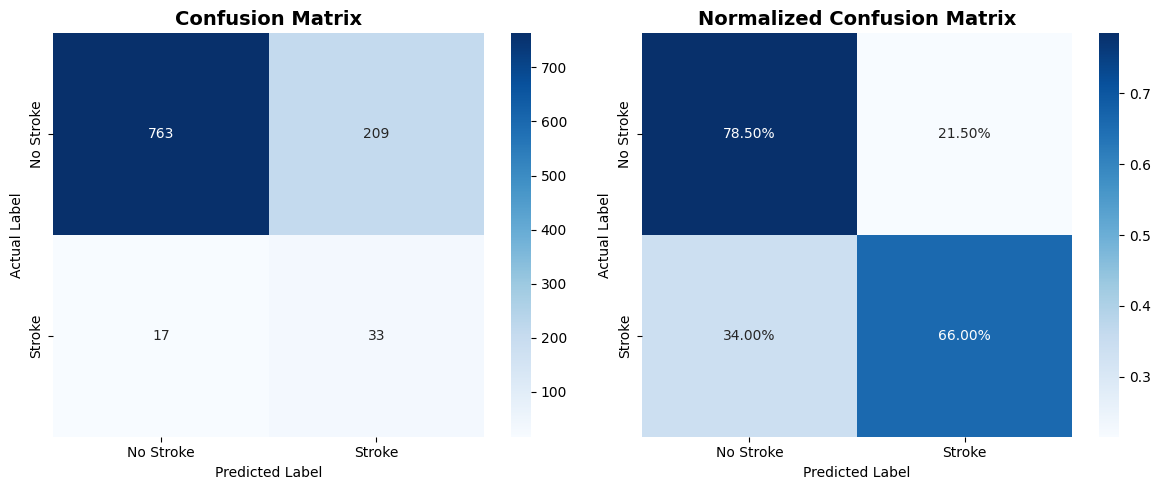


Additional Metrics:
Specificity (True Negative Rate): 0.7850
Negative Predictive Value: 0.9782
False Positive Rate: 0.2150
False Negative Rate: 0.3400


In [60]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'],
            ax=ax1)
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_ylabel('Actual Label')
ax1.set_xlabel('Predicted Label')

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'],
            ax=ax2)
ax2.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
ax2.set_ylabel('Actual Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Calculate additional metrics
TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP)
npv = TN / (TN + FN)  # Negative Predictive Value

print("\nAdditional Metrics:")
print(f"Specificity (True Negative Rate): {specificity:.4f}")
print(f"Negative Predictive Value: {npv:.4f}")
print(f"False Positive Rate: {FP/(FP+TN):.4f}")
print(f"False Negative Rate: {FN/(FN+TP):.4f}")

Sample data for model testing

In [61]:
# Function to predict stroke risk for new patient
def predict_stroke_risk(age, gender, hypertension, heart_disease, ever_married,
                        work_type, residence_type, avg_glucose_level, bmi, smoking_status):
    """
    Predict stroke risk for a new patient

    Parameters:
    - age: int/float
    - gender: 'Male', 'Female', or 'Other'
    - hypertension: 0 or 1
    - heart_disease: 0 or 1
    - ever_married: 'Yes' or 'No'
    - work_type: 'Private', 'Self-employed', 'Govt_job', 'children', or 'Never_worked'
    - residence_type: 'Urban' or 'Rural'
    - avg_glucose_level: float
    - bmi: float
    - smoking_status: 'formerly smoked', 'never smoked', 'smokes', or 'Unknown'

    Returns: dict with prediction and probability
    """

    # Create dataframe with input
    input_data = pd.DataFrame([[gender, hypertension, heart_disease, ever_married,
                               residence_type, age, avg_glucose_level, bmi,
                               work_type, smoking_status]],
                             columns=['gender', 'hypertension', 'heart_disease',
                                     'ever_married', 'Residence_type', 'age',
                                     'avg_glucose_level', 'bmi', 'work_type',
                                     'smoking_status'])

    # Encode categorical variables
    input_data['gender'] = label_encoders['gender'].transform(input_data['gender'])
    input_data['ever_married'] = label_encoders['ever_married'].transform(input_data['ever_married'])
    input_data['Residence_type'] = label_encoders['Residence_type'].transform(input_data['Residence_type'])

    # One-hot encode work_type and smoking_status
    input_data = pd.get_dummies(input_data, columns=['work_type', 'smoking_status'])

    # Add missing columns
    for col in X.columns:
        if col not in input_data.columns:
            input_data[col] = 0

    # Scale numerical features
    input_data[numerical_features] = scaler.transform(input_data[numerical_features])

    # Reorder columns
    input_data = input_data[X.columns]

    # Make prediction
    probability = model.predict(input_data, verbose=0)[0][0]
    prediction = 1 if probability > 0.5 else 0

    return {
        'prediction': 'Stroke Risk' if prediction == 1 else 'No Stroke Risk',
        'probability': probability,
        'risk_percentage': f"{probability * 100:.2f}%"
    }

# Test example
print("Example Prediction:")
print("-" * 40)
example_result = predict_stroke_risk(
    age=65, gender='Male', hypertension=1, heart_disease=0, ever_married='Yes',
    work_type='Private', residence_type='Urban', avg_glucose_level=120.5,
    bmi=28.5, smoking_status='formerly smoked'
)

for key, value in example_result.items():
    print(f"{key}: {value}")

Example Prediction:
----------------------------------------
prediction: Stroke Risk
probability: 0.7857893109321594
risk_percentage: 78.58%
